# CNN Model Development

## Machine Learning-Based Context-Aware Urban Acoustic Event Classification for Smart Noise Governance

This notebook develops a Convolutional Neural Network (CNN) model for classifying urban acoustic events. The objective is to improve contextual understanding of urban noise by automatically identifying the source of sound rather than relying solely on sound intensity measurements.

The model is trained using the UrbanSound8K dataset and forms the core intelligence component of the proposed Smart Noise Governance System.

Expected output:

- Trained CNN model
- Classification metrics
- Confusion matrix
- Training and validation performance curves
- Saved production-ready model

## Project Context

Traditional noise monitoring systems primarily rely on decibel measurements. While these systems can detect loud sounds, they often fail to identify the source of the noise.

For example:

- Traffic noise
- Construction activity
- Religious gatherings
- Entertainment venues

may produce similar sound levels while requiring different management responses.

This project aims to provide contextual acoustic intelligence by classifying urban sounds into meaningful categories that can support decision-making by businesses, venue operators, and regulatory authorities.

## Dataset Description

The UrbanSound8K dataset is used as the primary training dataset.

Dataset characteristics:

- 8,732 labeled audio recordings
- 10 predefined sound classes
- Distributed across 10 folds
- Standard benchmark dataset for urban sound classification

For this project, selected sound categories are mapped to the target classes required by the proposed system:

- Traffic
- Construction
- Entertainment
- Worship
- Normal Urban Ambience

The dataset provides sufficient diversity to train and evaluate deep learning models for acoustic event recognition.

In [ ]:
!git clone https://github.com/DavidDau/Urban-Noise-Governance-System.git
%cd Urban-Noise-Governance-System
!git checkout cnn-experiments

Cloning into 'Urban-Noise-Governance-System'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 77 (delta 20), reused 66 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 223.58 KiB | 31.94 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/Urban-Noise-Governance-System
Branch 'cnn-experiments' set up to track remote branch 'cnn-experiments' from 'origin'.
Switched to a new branch 'cnn-experiments'


## Environment Setup

This section connects Google Colab to Google Drive.

Google Drive stores:

- UrbanSound8K dataset
- Trained models
- Generated outputs
- Experiment artifacts

This allows large datasets and trained models to remain separate from the GitHub repository while maintaining reproducibility.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Verification

Before model development begins, the dataset location must be verified.

This step confirms:

1. The dataset exists.
2. The folder structure is correct.
3. Audio files are accessible.

Successful execution indicates that the training environment is ready.

In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/UrbanNoiseProject/datasets/UrbanSound8K"

print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset exists: True


## Dependency Installation

This section installs the libraries required for:

- Audio processing
- Deep learning
- Data visualization
- Model evaluation

These libraries form the foundation of the CNN training pipeline.

In [ ]:
!pip install librosa -q
!pip install tensorflow -q
!pip install scikit-learn -q
!pip install pandas -q
!pip install matplotlib -q
!pip install tqdm -q

## Library Imports

The required Python libraries are imported for data handling, audio processing, visualization, and deep learning.

In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


In [ ]:
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


## Dataset Exploration

Before training the CNN model, it is important to understand the structure of the dataset and the distribution of sound classes.

This section loads the UrbanSound8K metadata file and explores:

- Available sound categories
- Number of samples per class
- Dataset balance
- Suitability for training

Understanding the dataset helps identify potential challenges such as class imbalance and supports informed model design decisions.

In [ ]:
METADATA_PATH = (
    "/content/drive/MyDrive/"
    "UrbanNoiseProject/datasets/"
    "UrbanSound8K/UrbanSound8K.csv"
)

metadata = pd.read_csv(METADATA_PATH)

print("Dataset Shape:")
print(metadata.shape)

metadata.head()

Dataset Shape:
(8732, 8)


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


## Available Sound Classes

The UrbanSound8K dataset contains multiple urban sound categories.

The purpose of this analysis is to identify which sound classes can contribute to the target categories required by the Smart Noise Governance System.

In [ ]:
metadata["class"].value_counts()


,count
class,
dog_bark,1000
children_playing,1000
air_conditioner,1000
street_music,1000
jackhammer,1000
engine_idling,1000
drilling,1000
siren,929
car_horn,429


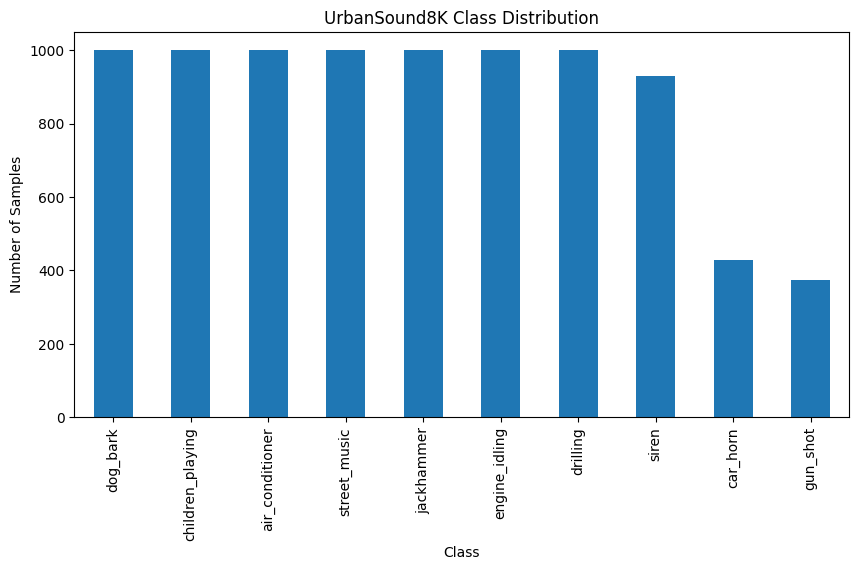

In [ ]:
OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "UrbanNoiseProject/outputs/figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

metadata["class"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("UrbanSound8K Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.savefig(
    f"{OUTPUT_DIR}/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Target Class Mapping

UrbanSound8K was not originally designed for noise governance applications.

Therefore, selected classes are mapped to project-specific categories.

The worship category is not represented in the public dataset and will be incorporated later using locally collected recordings from Kigali.

This approach allows the development of an initial proof-of-concept model while acknowledging dataset limitations.

In [ ]:
metadata["class"].value_counts()

,count
class,
dog_bark,1000
children_playing,1000
air_conditioner,1000
street_music,1000
jackhammer,1000
engine_idling,1000
drilling,1000
siren,929
car_horn,429


## Governance-Oriented Class Mapping

The original UrbanSound8K dataset contains ten environmental sound classes.

However, not all classes are relevant to the objectives of Smart Noise Governance.

I selected UrbanSound8K categories are grouped into broader governance oriented categories improve alignment with the project goals.

In [ ]:
governance_mapping = {
    "engine_idling": "Traffic",
    "car_horn": "Traffic",

    "jackhammer": "Construction",
    "drilling": "Construction",

    "street_music": "Entertainment",

    "air_conditioner": "Ambience"
}

Filtering the dataset

In [ ]:
metadata_filtered = metadata[
    metadata["class"].isin(
        governance_mapping.keys()
    )
].copy()

metadata_filtered["target_class"] = (
    metadata_filtered["class"]
    .map(governance_mapping)
)

metadata_filtered.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class,target_class
9,100648-1-0-0.wav,100648,4.823402,5.471927,2,10,1,car_horn,Traffic
10,100648-1-1-0.wav,100648,8.998279,10.052132,2,10,1,car_horn,Traffic
11,100648-1-2-0.wav,100648,16.699509,17.104837,2,10,1,car_horn,Traffic
12,100648-1-3-0.wav,100648,17.631764,19.253075,2,10,1,car_horn,Traffic
13,100648-1-4-0.wav,100648,25.332994,27.197502,2,10,1,car_horn,Traffic


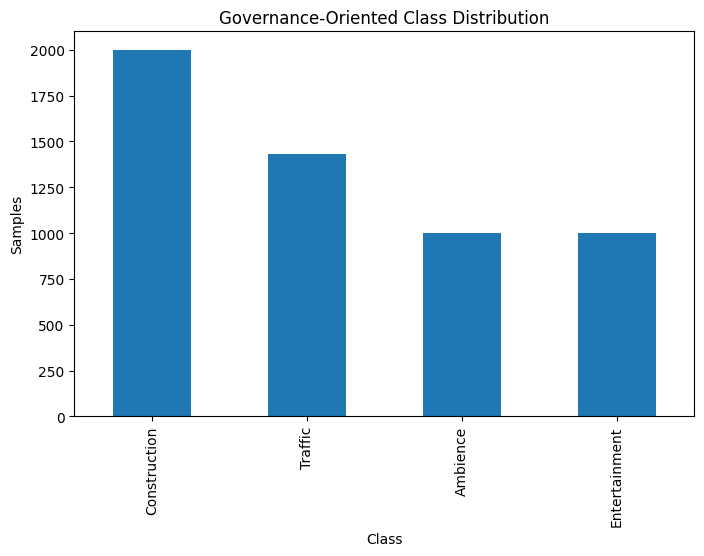

In [ ]:
### Keeping these figures

metadata_filtered["target_class"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Governance-Oriented Class Distribution"
)

plt.xlabel("Class")
plt.ylabel("Samples")

plt.savefig(
    f"{OUTPUT_DIR}/governance_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
metadata_filtered["target_class"].value_counts()

,count
target_class,
Construction,2000
Traffic,1429
Ambience,1000
Entertainment,1000


# Mel Spectrogram Dataset

## Feature Generation using Mel Spectrograms

Audio signals are transformed into Mel Spectrograms before training.

A Mel Spectrogram represents how sound energy changes across frequency bands over time.

This representation is commonly used in acoustic event classification because it:

- Preserves frequency information
- Captures temporal patterns
- Improves CNN performance
- Mimics aspects of human auditory perception

The generated spectrograms will serve as inputs to the CNN model.

In [ ]:
import librosa
import numpy as np
from tqdm import tqdm

In [ ]:
def extract_mel_spectrogram(
    audio_path,
    sample_rate=22050,
    n_mels=128,
    max_length=128
):
    """
    Load audio and convert to Mel Spectrogram.
    """

    audio, sr = librosa.load(
        audio_path,
        sr=sample_rate
    )

    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels
    )

    mel_spec_db = librosa.power_to_db(
        mel_spec,
        ref=np.max
    )

    if mel_spec_db.shape[1] < max_length:

        pad_width = (
            max_length - mel_spec_db.shape[1]
        )

        mel_spec_db = np.pad(
            mel_spec_db,
            pad_width=((0, 0), (0, pad_width)),
            mode="constant"
        )

    else:

        mel_spec_db = mel_spec_db[:, :max_length]

    return mel_spec_db

## Dataset Preparation

This section processes every selected audio recording and converts it into a fixed-size Mel Spectrogram.

Each spectrogram is associated with a target class label.

The resulting dataset will be used for CNN training.

In [ ]:
def build_audio_path(row):

    return os.path.join(
        DATASET_PATH,
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

In [ ]:
X = []
y = []

for _, row in tqdm(
    metadata_filtered.iterrows(),
    total=len(metadata_filtered)
):

    try:

        audio_path = build_audio_path(row)

        features = extract_mel_spectrogram(
            audio_path
        )

        X.append(features)

        y.append(
            row["target_class"]
        )

    except Exception as e:

        continue

 39%|███▉      | 2133/5429 [30:35<44:33,  1.23it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
 95%|█████████▌| 5163/5429 [1:13:23<03:52,  1.14it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
 95%|█████████▌| 5166/5429 [1:13:25<03:09,  1.39it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
100%|██████████| 5429/5429 [1:17:01<00:00,  1.17it/s]


In [ ]:
X = np.array(X)
y = np.array(y)

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (5429, 128, 128)
Labels Shape: (5429,)


In [ ]:
OUTPUT_PATH = (
    "/content/drive/MyDrive/"
    "UrbanNoiseProject/outputs"
)

In [ ]:
np.save(
    f"{OUTPUT_PATH}/X_spectrograms.npy",
    X
)

np.save(
    f"{OUTPUT_PATH}/y_labels.npy",
    y
)

In [ ]:
print(
    "Saved:",
    os.path.exists(
        f"{OUTPUT_PATH}/X_spectrograms.npy"
    )
)

print(
    "Saved:",
    os.path.exists(
        f"{OUTPUT_PATH}/y_labels.npy"
    )
)

Saved: True
Saved: True


In [ ]:
print(X.shape)
print(y.shape)

(5429, 128, 128)
(5429,)


## Label Encoding

Machine learning models cannot directly process textual class labels.

This section converts the target categories into numerical representations while preserving the mapping between classes and encoded values.

The encoded labels will be used during model training and evaluation.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class Mapping")

for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Class Mapping
Ambience -> 0
Construction -> 1
Entertainment -> 2
Traffic -> 3


In [ ]:
import joblib

MODEL_DIR = (
    "/content/drive/MyDrive/"
    "UrbanNoiseProject/models"
)

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(
    label_encoder,
    f"{MODEL_DIR}/label_encoder.pkl"
)

print("Label encoder saved")

Label encoder saved


## CNN Input Preparation

Convolutional Neural Networks expect image-like inputs with channel dimensions.

This section adds a channel dimension to the Mel Spectrograms so that they can be processed by the CNN architecture.

In [ ]:
X = X[..., np.newaxis]

print(X.shape)

(5429, 128, 128, 1)


## Dataset Splitting

The dataset is divided into training and testing subsets.

The training set is used to learn acoustic patterns while the testing set is reserved for evaluating model performance on previously unseen data.

This separation provides a realistic estimate of model effectiveness.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (4343, 128, 128, 1)
Testing Samples: (1086, 128, 128, 1)


## CNN Architecture Design

A Convolutional Neural Network is used to automatically learn acoustic patterns from Mel Spectrograms.

The network consists of:

- Convolutional layers for feature extraction
- Pooling layers for dimensionality reduction
- Dense layers for classification
- Softmax output layer for class probability estimation

The architecture is designed to balance performance and computational efficiency.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

num_classes = len(label_encoder.classes_)

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(128,128,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        num_classes,
        activation="softmax"
    )
])

In [ ]:
## Model compiling

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,700 (428.52 KB)

 Trainable params: 109,700 (428.52 KB)

 Non-trainable params: 0 (0.00 B)

## CNN Training Strategy

The CNN model is trained using supervised learning.

The objective is to learn distinguishing acoustic patterns associated with different urban noise sources.

The Adam optimization algorithm is used due to its efficiency and effectiveness in deep learning applications.

Training performance is monitored using:

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

These metrics help assess learning progress and detect potential overfitting.

In [ ]:
## Training

history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.3857 - loss: 1.3112 - val_accuracy: 0.5525 - val_loss: 1.1211
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4932 - loss: 1.1369 - val_accuracy: 0.5820 - val_loss: 1.0157
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5839 - loss: 0.9710 - val_accuracy: 0.5433 - val_loss: 0.9927
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6376 - loss: 0.8572 - val_accuracy: 0.6703 - val_loss: 0.7976
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6834 - loss: 0.7671 - val_accuracy: 0.7302 - val_loss: 0.6608
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7195 - loss: 0.6985 - val_accuracy: 0.7707 - val_loss: 0.6023
Epoch 7/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7486 - loss: 0.6284 - val_accuracy: 0.7302 - val_loss: 0.6621
Epoch 8/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7907 - loss: 0.5534 - val_acc

In [ ]:
## Saving the training history

import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "/content/drive/MyDrive/UrbanNoiseProject/outputs/cnn_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


## Model Preservation

The trained CNN model is saved for future inference, testing, and deployment within the Smart Noise Governance System.

In [ ]:
MODEL_PATH = (
    "/content/drive/MyDrive/"
    "UrbanNoiseProject/models/urban_noise_cnn.keras"
)

cnn_model.save(MODEL_PATH)

print("Model saved successfully.")

Model saved successfully.


## Model Evaluation

The trained model is evaluated using standard classification metrics.

Evaluation focuses on:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics provide a comprehensive assessment of classification performance.

In [ ]:
y_pred_probs = cnn_model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.919889502762431
Precision: 0.9215817289833204
Recall: 0.919889502762431
F1 Score: 0.919737184560353


## Confusion Matrix

The confusion matrix visualizes class-level prediction performance and highlights areas where the model may confuse different urban noise categories.

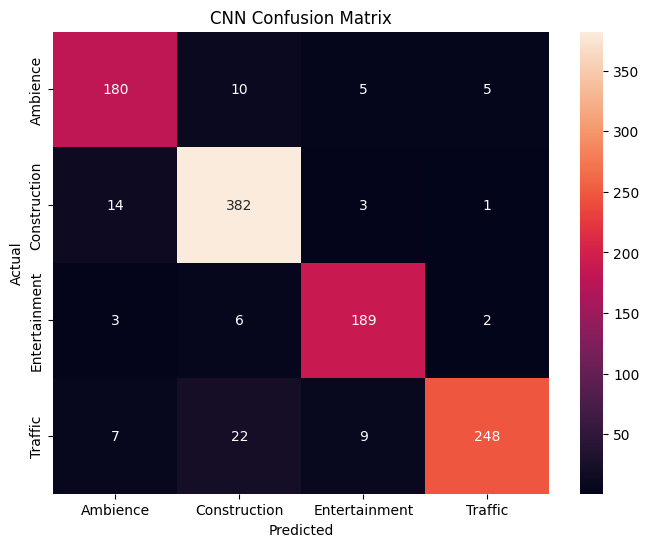

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

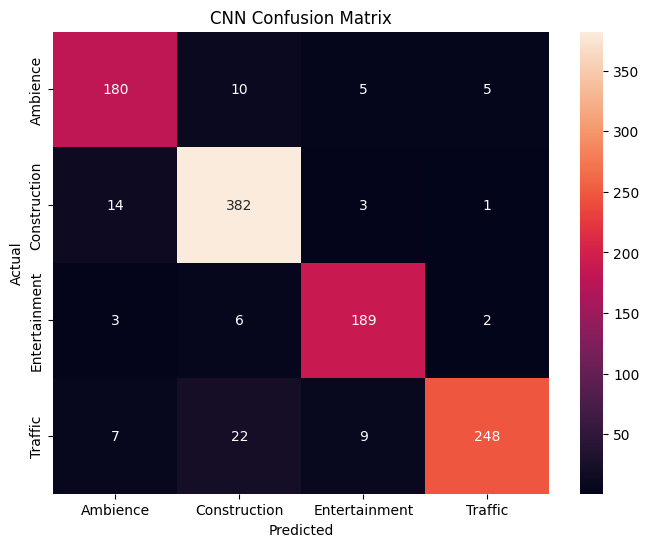

In [ ]:
REPORTS_DIR = (
    "/content/drive/MyDrive/"
    "UrbanNoiseProject/outputs"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.savefig(
    f"{REPORTS_DIR}/cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
with open(
    "/content/drive/MyDrive/UrbanNoiseProject/outputs/cnn_metrics.txt",
    "w"
) as f:

    f.write(f"Accuracy: {accuracy}\n")
    f.write(f"Precision: {precision}\n")
    f.write(f"Recall: {recall}\n")
    f.write(f"F1 Score: {f1}\n")

In [2]:
print(model.input_shape)
print(model.inputs)

NameError: name 'model' is not defined